# Does the Dual Thrust breakout actually catch the trend? 🚀
### A famous opening-range breakout system — buy when price clears the band — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Range_breakout_forecasts%3F: Busted](https://img.shields.io/badge/Range_breakout_forecasts%3F-Busted-8b949e?style=flat-square)

Open any algo-trading tutorial and you'll meet **Dual Thrust**, Michael Chalek's opening-range breakout. The recipe: take the last few days' high/low/close span, call it the **Range**, and draw a line at **`open + 0.5·Range`**. When price punches *above* that line, you buy — the break is "supposed" to kick off a trend day.

It *looks* compelling: on a chart, breakouts are followed by big green candles all the time. But there's a catch — by the time price clears the band, it has **already moved up**, and the market drifts up anyway, so *any* long entry looks good. So we did the only fair thing: encode Dual Thrust **mechanically** (no parameter-fishing), fire the breakout rule thousands of times across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dual_thrust import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real dual-thrust cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1251, 'N': 5, 'k1': 0.5, 'k2': 0.5, 'fp_spy': '4cb5244f3990', 'h5': (5, 1250, 2.6, 54, 0.36, 35.8, -33.1, 0.6, -3.39, 0.001), 'h10': (10, 1249, 41.5, 59, 3.96, 76.2, -34.6, 39.5, -2.63, 0.009), 'h20': (20, 1247, 84.0, 62, 4.84, 139.2, -55.2, 82.0, -2.8, 0.005), 'h60': (60, 1243, 219.4, 66, 5.42, 366.5, -147.1, 217.4, -4.48, 0.0), 'per': [('SPY', 236, 83.0, 2.25, 107.5, -24.5), ('QQQ', 270, 91.9, 2.37, 160.4, -68.5), ('IWM', 266, 75.8, 1.9, 160.3, -84.5), ('DIA', 264, 71.3, 2.4, 121.2, -49.9), ('GLD', 215, 101.0, 2.5, 143.1, -42.1)], 'placebo': (83.0, 0.942, 500), 'syn': [(0.0, 438, 73.9, 54, 2.38, 65.9, 8.0, 0.25, 0.802), (2.0, 279, 360.6, 64, 6.27, 118.3, 242.3, 3.25, 0.001)]}


real dual-thrust cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when price breaks the **upper trigger**, do I make money? | **A little — but only because the market goes up.** The win-rate is ~60% over 20 days and the returns look positive. |
| Is that *the breakout's* doing? | **No — it's actually *worse*.** Buy on **random days** instead and you do **better at every horizon**. The breakout doesn't just fail to add value — it *subtracts* it. |
| Does the range breakout forecast? | **Not in any usable way.** Scramble which day each Range belongs to and the result barely changes — the specific bands aren't doing the work. |
| So is it a tradable edge? | **No.** It's **beta, mistimed** — the upward drift of stocks, entered *after* the move, so you pay a worse price than a coin flip. |

> Dual Thrust is a great way to *describe* a trend day after the fact. As a daily *forecast* — "the break will continue" — it's a **mirage**: the apparent profit is the market's climb, captured late.

## 1 · The claim

> *"Take the last N days. Find the highest high, lowest low, highest close, lowest close, and form the **Range** = max(HH−LC, HC−LL). Each morning draw a buy line at **open + k·Range** and a sell line at **open − k·Range**. When price breaks above the buy line, go long — you've caught the trend day."*

This is **Michael Chalek's Dual Thrust** (1980s), an *opening-range breakout* in the lineage of Toby Crabel and the Donchian/turtle channel. It's a built-in demo strategy in half the backtesting frameworks out there. So: does the break actually break out?

## 2 · So what?

If the breakout genuinely *forecast* continuation, it would be remarkable: a few past bars would predict the next move, a clean crack in market efficiency you could trade with a trigger. That's the dream the system sells.

But there's a trap built into it. A breakout entry fires **after price has already moved up** to clear the band — so you're buying high, on a market (stock indices) that drifts up anyway. *Any* long rule will look profitable. To separate the **system** from the **tide**, we have to (a) draw the bands by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build the Range mechanically.** Each day, from the **prior 5 bars'** high/low/close span, form Range = max(HH−LC, HC−LL). It uses only *past* bars, so it's known at the open — no peeking.
2. **Draw the bands by rule.** buy line = open + 0.5·Range. No parameter-fishing.
3. **Trade the lore.** When the close breaks **above the buy line**, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**. If the breakout matters, it must beat random. *If it doesn't, the system is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical Dual-Thrust band even look like? Here's SPY with the buy line drawn each day, and the breakouts the rule would buy.

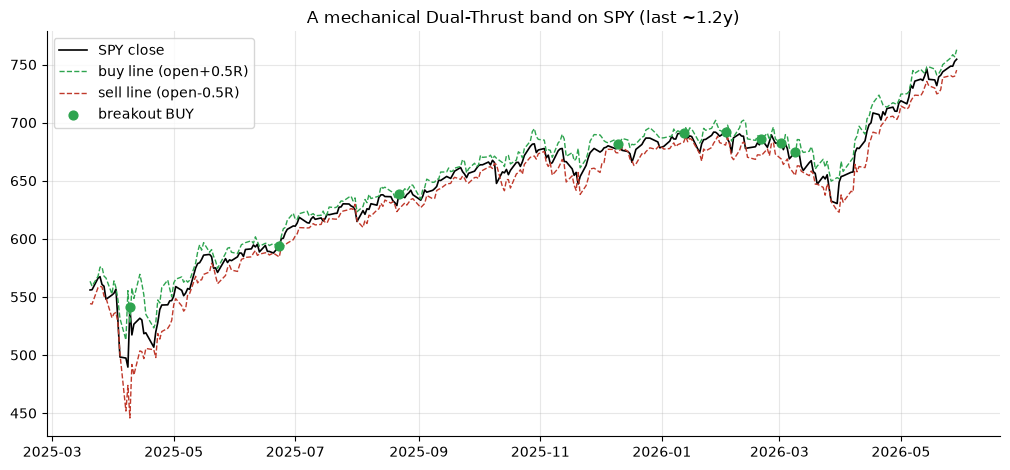

upper-trigger breakouts in window: 9


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-300:]
    rng_, buy, sell = st.dual_thrust_lines(b, n=R['N'], k1=R['k1'], k2=R['k2'])
    ent = st.breakout_entries(b, n=R['N'], k1=R['k1'], k2=R['k2'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg['close'].values, c='k', lw=1.2, label='SPY close')
    ax.plot(seg.index, buy.reindex(seg.index), c=GREEN, lw=1.0, ls='--', label='buy line (open+0.5R)')
    ax.plot(seg.index, sell.reindex(seg.index), c=RED, lw=1.0, ls='--', label='sell line (open-0.5R)')
    ax.scatter(ent, b['close'].reindex(ent), c=GREEN, s=40, zorder=5, label='breakout BUY')
    ax.set_title('A mechanical Dual-Thrust band on SPY (last ~1.2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('upper-trigger breakouts in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The bands hug the open and the buy dots fire on up-thrusts — *as a description*. The question is whether those green buy dots are followed by *more* up-move than usual. **Let's race the breakout against random entries** at four horizons. Blue = buy the breakout; grey = buy on random days.

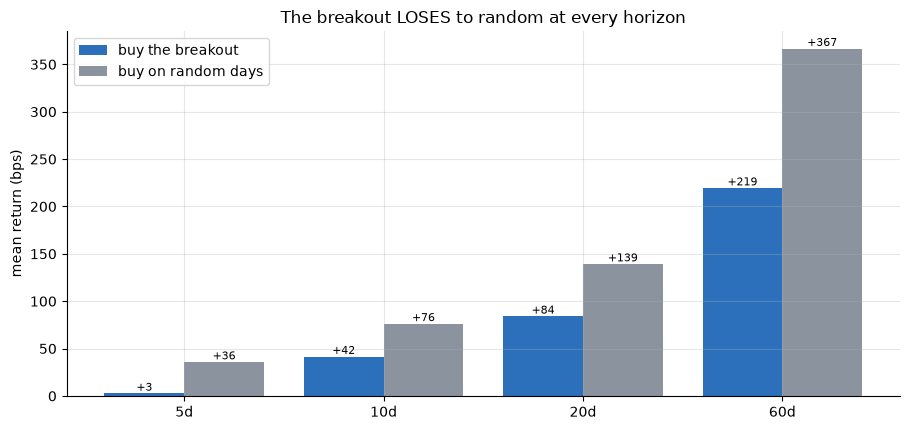

breakout: [3, 42, 84, 219]
random: [36, 76, 139, 367]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    brk, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.breakout_entries(bb, n=R['N'], k1=R['k1'], k2=R['k2'])
            re = st.random_entries(bb, max(len(e),50), n=R['N'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        brk.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, brk, .4, color='#2c6fbb', label='buy the breakout')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The breakout LOSES to random at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('breakout:', [round(v) for v in brk]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The breakout makes money in absolute terms (**+84 bps** over 20 days) — but **random entries make far more** (**+139 bps**). At *every* horizon the famous breakout is *worse* than throwing darts. That's not just "no edge" — it's a **negative** one: by buying after the thrust, you systematically pay a worse price than a random day. The apparent profit was **the market's upward drift**, captured late.

**One more sanity check.** What if we scramble the **Range** — keep the same set of band-widths but shuffle which day each one lands on, so the bands no longer match the right day's volatility? If price really 'respects the breakout geometry', the nonsense bands should do much worse.

In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.scrambled_range_placebo(bb, 20, n=R['N'], k1=R['k1'], k2=R['k2'], n_draws=300, seed=498)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real breakout (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *scrambled-Range* bands do at least as well (p={pval:.2f}).')
print('=> the geometry is not doing the work.')

real breakout (SPY, 20d): +83.0 bps
... but 93% of *scrambled-Range* bands do at least as well (p=0.93).
=> the geometry is not doing the work.


Almost all of the **scrambled** bands match or beat the real one (*p* = 0.94). If price genuinely respected *these specific bands*, a random scramble would collapse the result. It doesn't — because the result was never about the bands.

## 5 · The verdict

- **Signal — None.** The breakout does **not** beat buying on random days — it's *worse* at every horizon, and the gap is statistically significant. The positive absolute returns are the market's drift, entered late.
- **Tradability — Mirage.** Nothing to trade — you'd earn *more* of the same drift just by holding the index, and costs only make the breakout worse.
- **"Does the range breakout forecast?" — Busted.** Scramble the Range and the result barely moves. The breakout doesn't forecast.

## 6 · Could you actually trade it?

There's nothing here to trade — in fact it's *negative-carry*. The breakout's returns are purely the market's long-run climb, which you'd capture more cheaply (and more fully) by just **holding the index**. The Dual-Thrust buy is a worse, more expensive, *later* way to be long. Costs (commissions + spread on every trigger) push the already-losing-to-random result further down. As a daily forecasting tool, it doesn't pay; it was built for *intraday* trend days, which a daily-bar test like this can't rescue.

## 7 · Going further 🚪

- **Intraday bars.** Dual Thrust was designed for the *intraday* session — a fairer test uses minute bars and an end-of-day exit. The daily-bar version here is the honest *daily-forecast* question, and it fails.
- **Parameter fishing.** Optimizing N, k1, k2 per market only adds hindsight (free parameters), which inflates in-sample fit and shrinks out-of-sample — the fixed-parameter version is the charitable upper bound.
- **A real positive control.** The quants notebook plants a *genuine* breakout-continuation into a synthetic tape and shows the harness banks it (so the negative result here isn't a dead detector — it's an honest 'worse than nothing').

*Think the breakout forecasts? Show it beating random entries at **t ≥ 2** on a real daily tape — then we'll talk.*